In [6]:
import numpy as np

import torch

# Logistic Regression

In [7]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(123)
n = 20000
p = 5
my_x = np.random.normal(0,2,size=(n,p))
beta = np.random.normal(0,1,size=(p,1)) * 0.1
beta[:3] += 2
my_logit = my_x @ beta
prob = 1/(1 + np.exp(-my_logit))
my_y = np.random.binomial(n=1, p=prob, size=(n, 1))
tensor_x = torch.Tensor(my_x) # transform to torch tensor
tensor_y = torch.Tensor(my_y)

my_dataset = TensorDataset(tensor_x,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size=2000, shuffle=True) # create your dataloader

In [8]:
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(p, 1)

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred


In [9]:
model = LogisticRegressionModel()

# Cross-Entropy Loss for classification
criterion = nn.BCEWithLogitsLoss()

# SGD optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [10]:
num_epochs = 1000
loss_seq = []
agg_loss_seq = []
for epoch in range(num_epochs):
    for batch_x, batch_y in my_dataloader:
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs[:,0], batch_y[:,0])
        
        print(f'Loss: {loss.item():.4f}')
        loss_seq.append(loss.item())

        # Backward and optimize
        loss.backward()
        optimizer.step()
    agg_loss_seq.append(loss.item())


Loss: 0.5999
Loss: 0.6006
Loss: 0.5828
Loss: 0.5885
Loss: 0.5825
Loss: 0.5768
Loss: 0.5729
Loss: 0.5671
Loss: 0.5793
Loss: 0.5561
Loss: 0.5598
Loss: 0.5580
Loss: 0.5597
Loss: 0.5525
Loss: 0.5449
Loss: 0.5328
Loss: 0.5364
Loss: 0.5422
Loss: 0.5371
Loss: 0.5236
Loss: 0.5233
Loss: 0.5258
Loss: 0.5267
Loss: 0.5125
Loss: 0.5207
Loss: 0.5067
Loss: 0.5101
Loss: 0.5018
Loss: 0.5034
Loss: 0.5119
Loss: 0.5035
Loss: 0.5076
Loss: 0.4940
Loss: 0.4821
Loss: 0.4881
Loss: 0.4863
Loss: 0.4900
Loss: 0.4687
Loss: 0.4804
Loss: 0.4834
Loss: 0.4738
Loss: 0.4654
Loss: 0.4724
Loss: 0.4708
Loss: 0.4696
Loss: 0.4673
Loss: 0.4594
Loss: 0.4649
Loss: 0.4614
Loss: 0.4576
Loss: 0.4493
Loss: 0.4538
Loss: 0.4617
Loss: 0.4475
Loss: 0.4437
Loss: 0.4480
Loss: 0.4495
Loss: 0.4385
Loss: 0.4509
Loss: 0.4287
Loss: 0.4441
Loss: 0.4297
Loss: 0.4318
Loss: 0.4301
Loss: 0.4346
Loss: 0.4346
Loss: 0.4293
Loss: 0.4281
Loss: 0.4131
Loss: 0.4299
Loss: 0.4190
Loss: 0.4176
Loss: 0.4200
Loss: 0.4140
Loss: 0.4189
Loss: 0.4205
Loss: 0.4020

In [11]:
print(model.linear.weight)
print(model.linear.bias)
print(beta.flatten())

Parameter containing:
tensor([[ 1.8992,  1.8734,  1.7176, -0.1936, -0.0666]], requires_grad=True)
Parameter containing:
tensor([-0.0495], requires_grad=True)
[ 2.07394631  2.02565893  1.88777469 -0.21443253 -0.05668384]


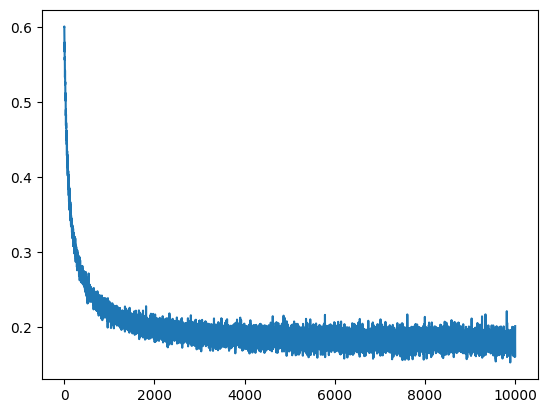

In [12]:
from matplotlib import pyplot as plt
plt.plot(loss_seq)

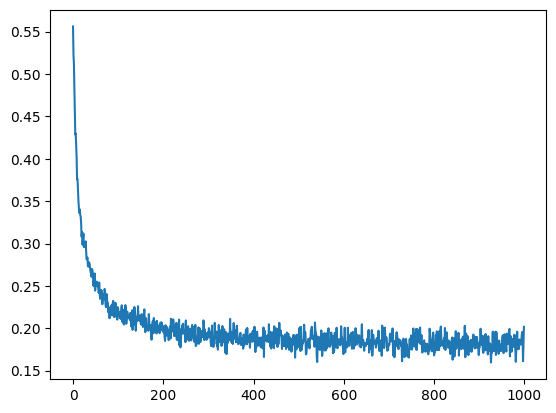

In [13]:
plt.plot(agg_loss_seq)